# Exercise

https://www.kaggle.com/code/anuya09/titanic-machine-learning-from-disaster

### 1. Import libraries

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

### 2. Read data

In [90]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

pass_df = test_df[["PassengerId"]]

In [91]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Checking Dimensions of Data

In [92]:
print("Training Dataset shape is: ", train_df.shape)
print("Testing Dataset shape is: ", test_df.shape)

Training Dataset shape is:  (891, 12)
Testing Dataset shape is:  (418, 11)


In [93]:
test_df[:3]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


### 4. Checking Duplicates Data

In [94]:
print(
    f"Duplicates in Train Dataset is: {train_df.duplicated().sum()} ({100 * train_df.duplicated().sum() / len(train_df)}%)")
print(
    f"Duplicates in Test Dataset is: {test_df.duplicated().sum()} ({100 * test_df.duplicated().sum() / len(test_df)}%)")

Duplicates in Train Dataset is: 0 (0.0%)
Duplicates in Test Dataset is: 0 (0.0%)


### 5. Checking Data types

In [95]:
print("Data Types of Training Data is: \n")
print(train_df.dtypes)

Data Types of Training Data is: 

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [96]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 6.a Checking Total Number & Percentage of Missing Values in Training Dataset

In [97]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [98]:
df_missing = (train_df.isnull().sum()[train_df.isnull().sum() > 0]).to_frame().rename(
    columns={0: "Number of Missing values"})
df_missing["% of Missing Values"] = round((100 * train_df.isnull().sum()[train_df.isnull().sum() > 0] / len(train_df)),
                                          2)
df_missing

,Number of Missing values,% of Missing Values
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


### 6.b Checking Total Number & Percentage of Missing Values in Test Dataset

In [99]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [100]:
df_missing = (test_df.isnull().sum()[test_df.isnull().sum() > 0]).to_frame().rename(
    columns={0: "Number of Missing values"})
df_missing["% of Missing Values"] = round((100 * test_df.isnull().sum()[test_df.isnull().sum() > 0] / len(test_df)), 2)
df_missing

,Number of Missing values,% of Missing Values
Age,86,20.57
Fare,1,0.24
Cabin,327,78.23


### 7. Visualizing (missing and existing) numbers

In [101]:
train_df.notna().sum()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

Text(0.5, 1.0, 'Training Dataset vs. Test Dataset (nr of values)')

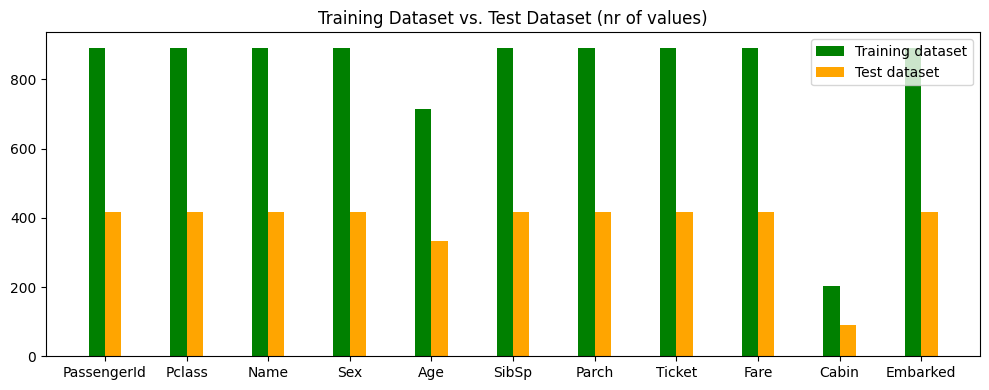

In [102]:
chart_x = train_df.drop('Survived', axis=1).notna().sum().index
chart_y1 = train_df.drop('Survived', axis=1).notna().sum()
chart_y2 = test_df.notna().sum()

width = 0.2
x = np.arange(len(chart_x))

plt.figure(figsize=(10, 4), tight_layout=True)
plt.bar(x - width / 2, chart_y1, width, color="green")
plt.bar(x + width / 2, chart_y2, width, color="orange")
plt.xticks(x, chart_x)
plt.legend(["Training dataset", "Test dataset"])
plt.title("Training Dataset vs. Test Dataset (nr of values)")

### 8. Handling missing values

In [103]:
# drop unwanted columns
train_df = train_df.drop(['Cabin', 'Name', 'Ticket', 'Fare', 'PassengerId'], axis=1)
test_df = test_df.drop(['Cabin', 'Name', 'Ticket', 'Fare', 'PassengerId'], axis=1)

In [104]:
# train_df
mean_imputer = SimpleImputer(strategy='mean')
train_df['Age'] = mean_imputer.fit_transform(train_df[['Age']])

train_df[5:8]

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
5,0,3,male,29.699118,0,0,Q
6,0,1,male,54.000000,0,0,S
7,0,3,male,2.000000,3,1,S


In [105]:
# test_df
mean_imputer = SimpleImputer(strategy='mean')
test_df['Age'] = mean_imputer.fit_transform(test_df[['Age']])

test_df[:3]

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,3,male,34.5,0,0,Q
1,3,female,47.0,1,0,S
2,2,male,62.0,0,0,Q


In [106]:
mean_imputer = SimpleImputer(strategy='most_frequent')
train_df.iloc[:, :] = mean_imputer.fit_transform(train_df)
test_df.iloc[:, :] = mean_imputer.fit_transform(test_df)

# no more null value left

In [107]:
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Embarked    0
dtype: int64

### 9. Categorical and numerical columns

In [108]:
cat_cols = train_df.select_dtypes(include=["object", "str", "bool"]).columns.tolist()
num_cols = train_df.select_dtypes(include=["int", "float"]).columns.tolist()

In [109]:
print("Categorical Columns:", cat_cols)
print("-" * 120)
print("Numerical Columns:", num_cols)

Categorical Columns: ['Sex', 'Embarked']
------------------------------------------------------------------------------------------------------------------------
Numerical Columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch']


In [110]:
train_df[:3]

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S


### 10. Checking Cardinality of Categorical Features

In [111]:
print("Cardinality of features in numerical data is: ")
print(train_df.select_dtypes(include=["int", "float"]).nunique())
print("-" * 50)

print("Cardinality of features in categorical data is: ")
print(test_df.select_dtypes(include=["object", "str", "bool"]).nunique())

Cardinality of features in numerical data is: 
Survived     2
Pclass       3
Age         89
SibSp        7
Parch        7
dtype: int64
--------------------------------------------------
Cardinality of features in categorical data is: 
Sex         2
Embarked    3
dtype: int64


### 11. Handle categorical variables

- drop
- dummy
- ordinal encoding
- one-hot encoding
- label encoding

In [112]:
train_df[:3]

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S


In [113]:
label_encoder = LabelEncoder()
ordinal_cat_cols = ["Pclass", "SibSp", "Parch"]

train_df[ordinal_cat_cols] = train_df[ordinal_cat_cols].apply(label_encoder.fit_transform)
test_df[ordinal_cat_cols] = test_df[ordinal_cat_cols].apply(label_encoder.fit_transform)

In [114]:
nominal_cat_cols = ["Sex", "Embarked"]

train_df = pd.get_dummies(train_df, columns=nominal_cat_cols)
test_df = pd.get_dummies(test_df, columns=nominal_cat_cols)

In [115]:
train_df[:5]

,Survived,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,2,22.0,1,0,False,True,False,False,True
1,1,0,38.0,1,0,True,False,True,False,False
2,1,2,26.0,0,0,True,False,False,False,True
3,1,0,35.0,1,0,True,False,False,False,True
4,0,2,35.0,0,0,False,True,False,False,True


In [116]:
test_df[:5]

,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,2,34.5,0,0,False,True,False,True,False
1,2,47.0,1,0,True,False,False,False,True
2,1,62.0,0,0,False,True,False,True,False
3,2,27.0,0,0,False,True,False,False,True
4,2,22.0,1,1,True,False,False,False,True


### 12. Selecting Features & Labels For Model Training

In [117]:
X = train_df.drop(columns=["Survived"])
y = train_df["Survived"]

### 13. Feature Scaling

In [118]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
test_df_scaled = scaler.fit_transform(test_df)

### 14. Model training

In [119]:
# Splitting data for model which doesn't need scaled data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [120]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(712, 9) (712,)
(179, 9) (179,)


In [121]:
# Splitting data for model which needs scaled data

x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled = (
    train_test_split(X_scaled, y, test_size=0.2, random_state=1))

In [122]:
print(x_train_scaled.shape, y_train_scaled.shape)
print(x_test_scaled.shape, y_test_scaled.shape)

(712, 9) (712,)
(179, 9) (179,)


In [123]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

training_score = []
testing_score = []


def model_prediction(model):
    model.fit(x_train_scaled, y_train_scaled)
    x_train_predicted = model.predict(x_train_scaled)
    x_test_predicted = model.predict(x_test_scaled)
    a = accuracy_score(y_train_scaled, x_train_predicted) * 100
    b = accuracy_score(y_test_scaled, x_test_predicted) * 100
    training_score.append(a)
    testing_score.append(b)

    print(f"Accuracy_Score of {model} model on Training Data is:", a)
    print(f"Accuracy_Score of {model} model on Testing Data is:", b)
    print("------------------------------------------------------------------------")
    print(f"Precision Score of {model} model is:", precision_score(y_test_scaled, x_test_predicted))
    print(f"Recall Score of {model} model is:", recall_score(y_test_scaled, x_test_predicted))
    print(f"F1 Score of {model} model is:", f1_score(y_test_scaled, x_test_predicted))
    print("------------------------------------------------------------------------")

    print(f"Confusion Matrix of {model} model is:")
    cm = confusion_matrix(y_test_scaled, x_test_predicted)
    plt.figure(figsize=(8, 4))
    sns.heatmap(cm, annot=True, fmt="g", cmap="summer")
    plt.show()


### 15. Model evaluation

#### 15.1 Logistic-Regression Model

Accuracy_Score of LogisticRegression() model on Training Data is: 79.63483146067416
Accuracy_Score of LogisticRegression() model on Testing Data is: 79.88826815642457
------------------------------------------------------------------------
Precision Score of LogisticRegression() model is: 0.7605633802816901
Recall Score of LogisticRegression() model is: 0.7397260273972602
F1 Score of LogisticRegression() model is: 0.75
------------------------------------------------------------------------
Confusion Matrix of LogisticRegression() model is:


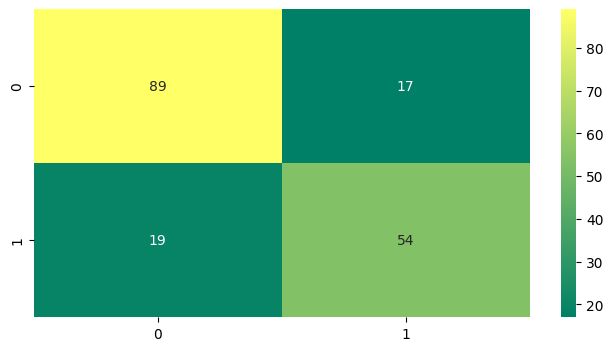

In [124]:
from sklearn.linear_model import LogisticRegression

model_prediction(LogisticRegression())

#### 15.2 KNeighborsClassifier Model

Accuracy_Score of KNeighborsClassifier() model on Training Data is: 85.67415730337079
Accuracy_Score of KNeighborsClassifier() model on Testing Data is: 76.53631284916202
------------------------------------------------------------------------
Precision Score of KNeighborsClassifier() model is: 0.803921568627451
Recall Score of KNeighborsClassifier() model is: 0.5616438356164384
F1 Score of KNeighborsClassifier() model is: 0.6612903225806451
------------------------------------------------------------------------
Confusion Matrix of KNeighborsClassifier() model is:


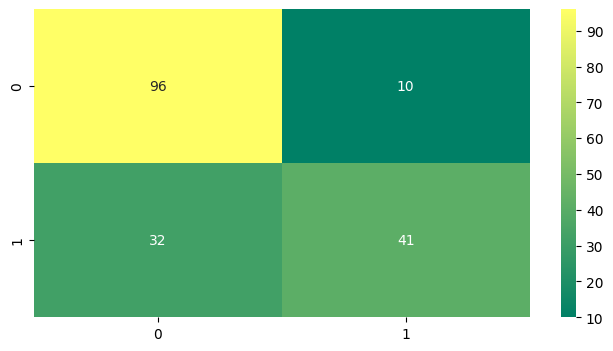

In [125]:
from sklearn.neighbors import KNeighborsClassifier

model_prediction(KNeighborsClassifier())

#### 15.3 Support-Vector-Classifier Model

Accuracy_Score of SVC() model on Training Data is: 85.25280898876404
Accuracy_Score of SVC() model on Testing Data is: 78.2122905027933
------------------------------------------------------------------------
Precision Score of SVC() model is: 0.8695652173913043
Recall Score of SVC() model is: 0.547945205479452
F1 Score of SVC() model is: 0.6722689075630253
------------------------------------------------------------------------
Confusion Matrix of SVC() model is:


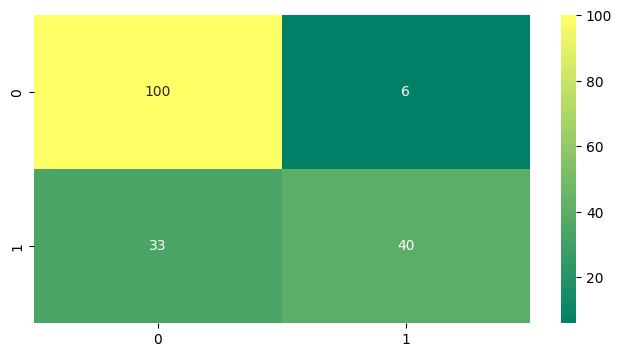

In [126]:
from sklearn.svm import SVC

model_prediction(SVC())

#### 15.4 Naive-Bayes Model

Accuracy_Score of GaussianNB() model on Training Data is: 79.35393258426966
Accuracy_Score of GaussianNB() model on Testing Data is: 77.09497206703911
------------------------------------------------------------------------
Precision Score of GaussianNB() model is: 0.7285714285714285
Recall Score of GaussianNB() model is: 0.6986301369863014
F1 Score of GaussianNB() model is: 0.7132867132867133
------------------------------------------------------------------------
Confusion Matrix of GaussianNB() model is:


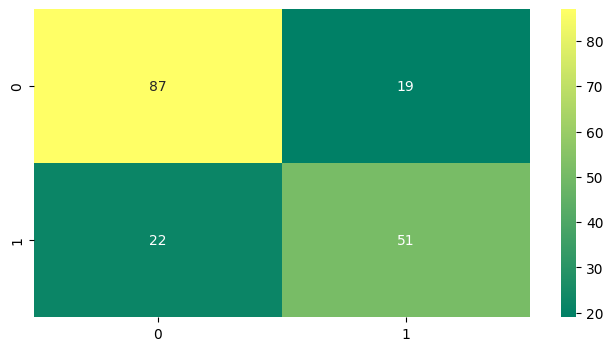

In [127]:
from sklearn.naive_bayes import GaussianNB

model_prediction(GaussianNB())

#### 15.5 Decision-Tree-Classifier Model

Accuracy_Score of DecisionTreeClassifier() model on Training Data is: 95.36516853932584
Accuracy_Score of DecisionTreeClassifier() model on Testing Data is: 77.09497206703911
------------------------------------------------------------------------
Precision Score of DecisionTreeClassifier() model is: 0.7424242424242424
Recall Score of DecisionTreeClassifier() model is: 0.6712328767123288
F1 Score of DecisionTreeClassifier() model is: 0.7050359712230215
------------------------------------------------------------------------
Confusion Matrix of DecisionTreeClassifier() model is:


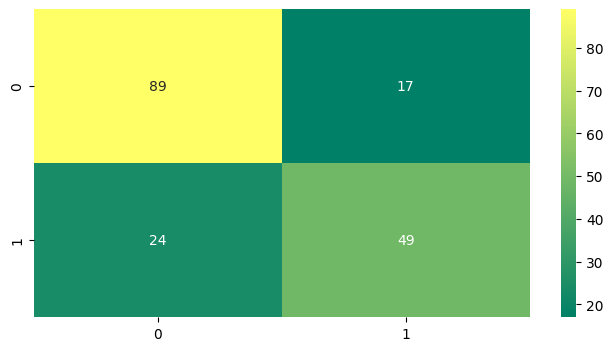

In [128]:
from sklearn.tree import DecisionTreeClassifier

model_prediction(DecisionTreeClassifier())

#### 15.6 Random-Forest-Classifier Model

Accuracy_Score of RandomForestClassifier() model on Training Data is: 95.36516853932584
Accuracy_Score of RandomForestClassifier() model on Testing Data is: 77.6536312849162
------------------------------------------------------------------------
Precision Score of RandomForestClassifier() model is: 0.7391304347826086
Recall Score of RandomForestClassifier() model is: 0.6986301369863014
F1 Score of RandomForestClassifier() model is: 0.7183098591549296
------------------------------------------------------------------------
Confusion Matrix of RandomForestClassifier() model is:


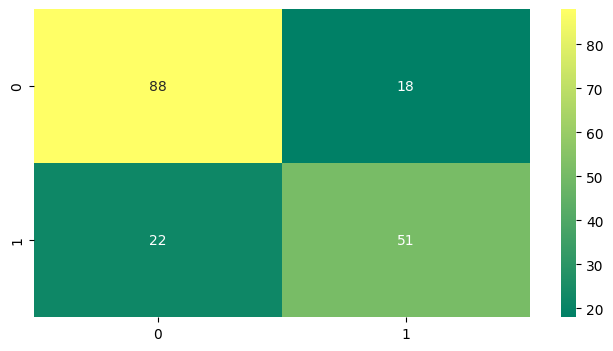

In [129]:
from sklearn.ensemble import RandomForestClassifier

model_prediction(RandomForestClassifier())

#### 15.7 Ada-Boost-Classifier Model

Accuracy_Score of AdaBoostClassifier() model on Training Data is: 82.86516853932584
Accuracy_Score of AdaBoostClassifier() model on Testing Data is: 79.3296089385475
------------------------------------------------------------------------
Precision Score of AdaBoostClassifier() model is: 0.78125
Recall Score of AdaBoostClassifier() model is: 0.684931506849315
F1 Score of AdaBoostClassifier() model is: 0.7299270072992701
------------------------------------------------------------------------
Confusion Matrix of AdaBoostClassifier() model is:


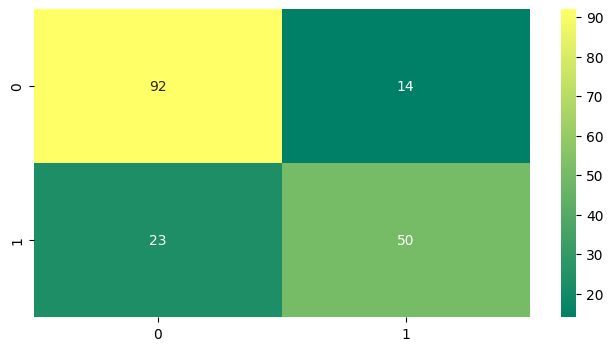

In [130]:
from sklearn.ensemble import AdaBoostClassifier

model_prediction(AdaBoostClassifier())

#### 15.8 Gradient-Boosting-Classifier Model

Accuracy_Score of GradientBoostingClassifier() model on Training Data is: 87.64044943820225
Accuracy_Score of GradientBoostingClassifier() model on Testing Data is: 77.6536312849162
------------------------------------------------------------------------
Precision Score of GradientBoostingClassifier() model is: 0.8235294117647058
Recall Score of GradientBoostingClassifier() model is: 0.5753424657534246
F1 Score of GradientBoostingClassifier() model is: 0.6774193548387096
------------------------------------------------------------------------
Confusion Matrix of GradientBoostingClassifier() model is:


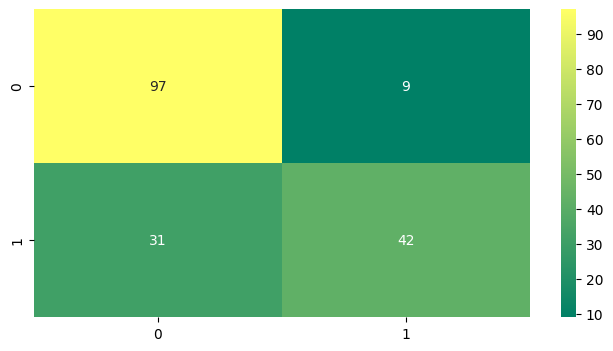

In [131]:
from sklearn.ensemble import GradientBoostingClassifier

model_prediction(GradientBoostingClassifier())

#### 15.9 XGBClassifier Model

Accuracy_Score of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) model on Training Data is: 92.69662921348315
Accuracy_Score of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None,

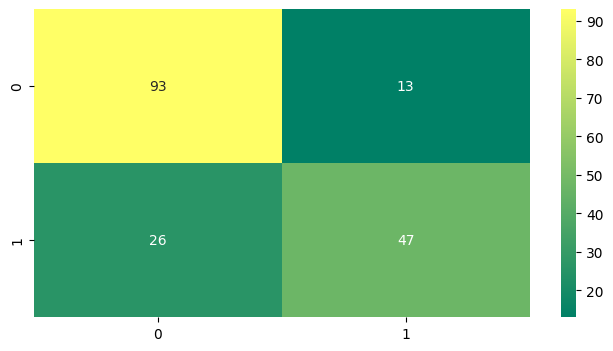

In [132]:
from xgboost import XGBClassifier

model_prediction(XGBClassifier())

#### 15.10 Cat-Boost-Classifier Model

Accuracy_Score of CatBoostClassifier(verbose=False) model on Training Data is: 88.20224719101124
Accuracy_Score of CatBoostClassifier(verbose=False) model on Testing Data is: 78.77094972067039
------------------------------------------------------------------------
Precision Score of CatBoostClassifier(verbose=False) model is: 0.8571428571428571
Recall Score of CatBoostClassifier(verbose=False) model is: 0.5753424657534246
F1 Score of CatBoostClassifier(verbose=False) model is: 0.6885245901639344
------------------------------------------------------------------------
Confusion Matrix of CatBoostClassifier(verbose=False) model is:


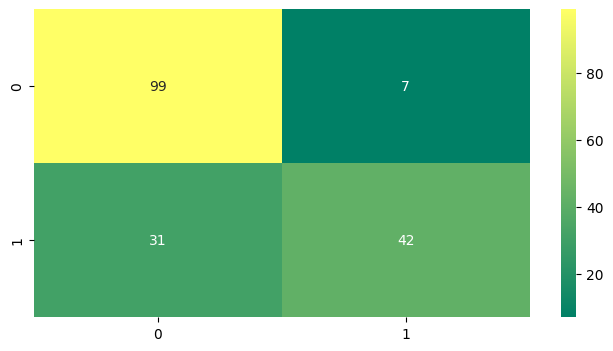

In [133]:
from catboost import CatBoostClassifier

model_prediction(CatBoostClassifier(verbose=False))

### 16. Model Evaluation Summary

In [134]:
models = ["Logistic Regression", "KNN", "SVM", "Naive Bayes", "Decision Tree", "Random Forest", "Ada Boost",
          "Gradient Boost", "XGBoost", "CatBoost"]

df = pd.DataFrame({"Algorithms":models,
                   "Training Score":training_score,
                   "Testing Score":testing_score})

In [135]:
df

,Algorithms,Training Score,Testing Score
0,Logistic Regression,79.634831,79.888268
1,KNN,85.674157,76.536313
2,SVM,85.252809,78.212291
3,Naive Bayes,79.353933,77.094972
4,Decision Tree,95.365169,77.094972
5,Random Forest,95.365169,77.653631
6,Ada Boost,82.865169,79.329609
7,Gradient Boost,87.640449,77.653631
8,XGBoost,92.696629,78.212291
9,CatBoost,88.202247,78.770950


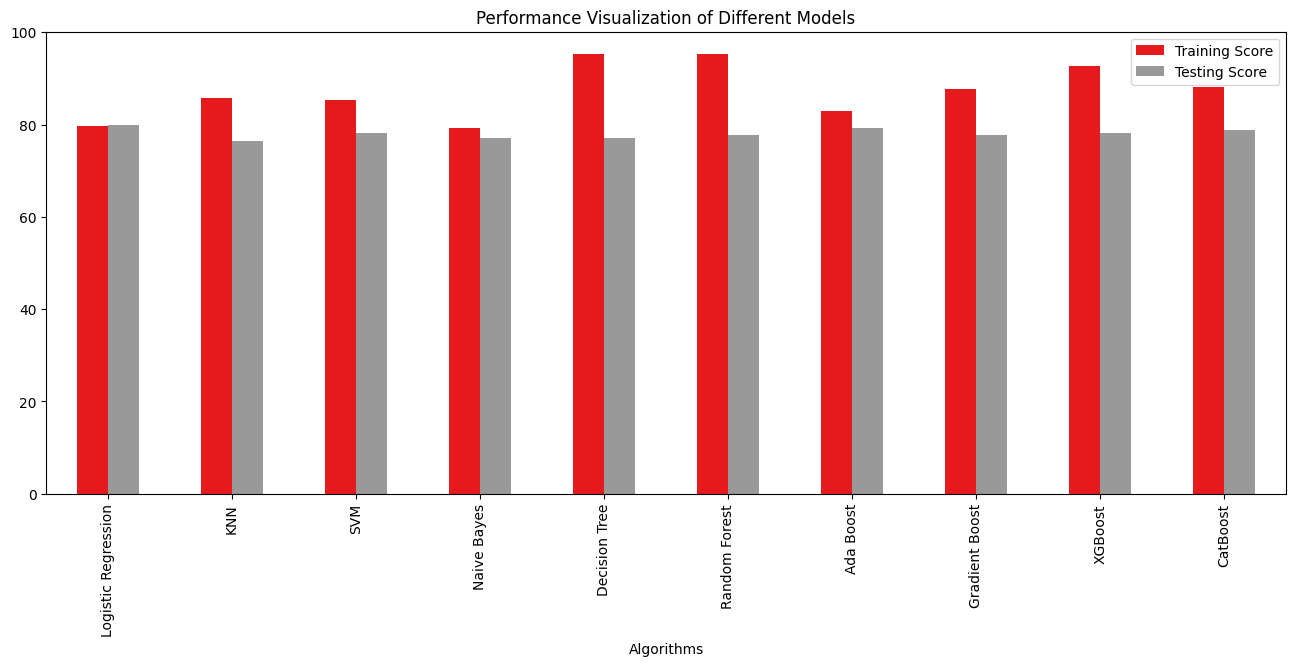

In [136]:
df.plot(x="Algorithms",y=["Training Score","Testing Score"], figsize=(16,6),kind="bar",
        title="Performance Visualization of Different Models",colormap="Set1")
plt.show()

### 18. Creating LGBM Model Using Best Parameters

In [137]:
from sklearn.model_selection import GridSearchCV

model2 = CatBoostClassifier(verbose=False)

parameters2 = {"learning_rate":[0.1,0.3,0.5,0.6,0.7],
              "random_state":[0,42,48,50],
               "depth":[8,9,10],
               "iterations":[35,40,50]}

grid_search2 = GridSearchCV(model2, parameters2, cv=5, n_jobs=-1)

grid_search2.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [8, 9, ...], 'iterations': [35, 40, ...], 'learning_rate': [0.1, 0.3, ...], 'random_state': [0, 42, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [138]:
grid_search2.best_score_

np.float64(0.8441445878065595)

In [139]:
grid_search2.best_params_

{'depth': 9, 'iterations': 50, 'learning_rate': 0.1, 'random_state': 42}

In [140]:
model2 = CatBoostClassifier(**grid_search2.best_params_,verbose=False)

In [141]:
model2.fit(x_train,y_train)

CatBoostClassifier(depth=9, iterations=50, learning_rate=0.1, random_state=42, verbose=False)

In [142]:
x_test_pred2 = model2.predict(x_test)

In [143]:
accuracy_score(y_test,x_test_pred2)

0.7821229050279329

In [144]:
pred = model2.predict(test_df)

In [145]:
pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [146]:
pass_df.head()

,PassengerId
0,892
1,893
2,894
3,895
4,896


In [147]:
pass_df["Survived"] = pred

In [148]:
pass_df.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [149]:
pass_df.shape

(418, 2)

In [150]:
# pass_df.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
